<a href="https://colab.research.google.com/github/T-Svitlichna/DTA_Python/blob/main/HomeWork/20_pandas_tasks_beginners_DTA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Практичні завдання з pandas для початківців

**Мета:** Набути базових навичок роботи з бібліотекою pandas для аналізу табличних даних.

**Інструкції:**
- Виконуйте завдання послідовно — кожне наступне спирається на попередні.
- Після виконання кожного завдання напишіть короткий висновок у комірці `**Висновок:**`.
- Не змінюйте код у комірках з підготовкою даних.

**Набір даних:** Умовна таблиця продажів інтернет-магазину за 2023 рік.

---
## Підготовка: Генерація тестових даних

Запустіть цю комірку перед початком роботи. Не змінюйте код.

In [3]:
import pandas as pd
import numpy as np

np.random.seed(42)
n = 200

categories = ['Електроніка', 'Одяг', 'Книги', 'Продукти', 'Спорт']
cities = ['Київ', 'Харків', 'Одеса', 'Дніпро', 'Львів']
payment_methods = ['Картка', 'Готівка', 'Онлайн']

df = pd.DataFrame({
    'order_id':        range(1001, 1001 + n),
    'date':            pd.date_range('2023-01-01', periods=n, freq='D')[:n],
    'category':        np.random.choice(categories, n),
    'product':         ['Товар_' + str(i) for i in np.random.randint(1, 51, n)],
    'city':            np.random.choice(cities, n),
    'quantity':        np.random.randint(1, 10, n),
    'price':           np.round(np.random.uniform(50, 5000, n), 2),
    'payment_method':  np.random.choice(payment_methods, n),
    'rating':          np.random.choice([1, 2, 3, 4, 5, np.nan], n, p=[0.05, 0.1, 0.15, 0.3, 0.3, 0.1]),
    'is_returned':     np.random.choice([True, False], n, p=[0.1, 0.9]),
})

# Додаємо кілька пропущених значень
df.loc[np.random.choice(df.index, 10, replace=False), 'city'] = np.nan
df.loc[np.random.choice(df.index, 5, replace=False), 'price'] = np.nan

# Розраховуємо загальну суму
df['total'] = df['quantity'] * df['price']

print('Дані успішно згенеровано. Рядків:', len(df))
print('Колонки:', list(df.columns))

Дані успішно згенеровано. Рядків: 200
Колонки: ['order_id', 'date', 'category', 'product', 'city', 'quantity', 'price', 'payment_method', 'rating', 'is_returned', 'total']


---
## Завдання 1 (Легке). Перший погляд на дані

Виведіть перші 10 рядків датафрейму `df` та отримайте загальну інформацію про нього (кількість рядків, колонок, типи даних) за допомогою методів `head()` та `info()`.

In [4]:
# Ваш код тут
display(df.head())
df.iloc[1:3, 5:8]
df.info()



,order_id,date,category,product,city,quantity,price,payment_method,rating,is_returned,total
0,1001,2023-01-01,Продукти,Товар_34,Київ,1,963.38,Картка,5.0,False,963.38
1,1002,2023-01-02,Спорт,Товар_6,Львів,6,1086.28,Картка,4.0,False,6517.68
2,1003,2023-01-03,Книги,Товар_22,Дніпро,4,1883.84,Готівка,5.0,False,7535.36
3,1004,2023-01-04,Спорт,Товар_11,Дніпро,1,2448.39,Картка,5.0,False,2448.39
4,1005,2023-01-05,Спорт,Товар_48,Дніпро,7,3110.36,Онлайн,3.0,False,21772.52


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        200 non-null    int64         
 1   date            200 non-null    datetime64[ns]
 2   category        200 non-null    object        
 3   product         200 non-null    object        
 4   city            190 non-null    object        
 5   quantity        200 non-null    int64         
 6   price           195 non-null    float64       
 7   payment_method  200 non-null    object        
 8   rating          177 non-null    float64       
 9   is_returned     200 non-null    bool          
 10  total           195 non-null    float64       
dtypes: bool(1), datetime64[ns](1), float64(3), int64(2), object(4)
memory usage: 15.9+ KB


**Висновок:** *(Напишіть, скільки рядків і колонок у датафреймі, які типи даних зустрічаються, чи є пропущені значення)*



---
## Завдання 2 (Легке). Описова статистика

Використайте метод `describe()` для отримання описової статистики числових колонок. Окремо виведіть мінімум, максимум і середнє значення колонки `price`.

In [5]:
# Ваш код тут
df.describe().round(2)

,order_id,date,quantity,price,rating,total
count,200.00,200,200.00,195.00,177.00,195.00
mean,1100.50,2023-04-10 12:00:00,4.70,2500.58,3.81,11629.10
min,1001.00,2023-01-01 00:00:00,1.00,139.65,1.00,149.35
25%,1050.75,2023-02-19 18:00:00,2.00,1288.22,3.00,3893.96
50%,1100.50,2023-04-10 12:00:00,5.00,2517.29,4.00,8746.84
75%,1150.25,2023-05-30 06:00:00,7.00,3706.98,5.00,16922.42
max,1200.00,2023-07-19 00:00:00,9.00,4950.30,5.00,44324.64
std,57.88,NaN,2.62,1380.07,1.17,9968.29


**Висновок:** *(Опишіть діапазон цін, середнє значення, чи є суттєвий розкид)*
В колонці ціна - 5 пропущений значень, середнє значення не значно більше за медіану(50%), що говорить про те, що дані розподілені в ціломк рівномірно. Стандартне відхилення говорить про те що цей датафрейм має  великий розкид по ціні, тому що містить різні групи товарів, за відповідно різною ціною.

---
## Завдання 3 (Легке). Пропущені значення

Знайдіть кількість пропущених значень у кожній колонці за допомогою `isnull().sum()`. Визначте, який відсоток рядків має пропущені значення хоча б в одній колонці (`dropna()` та `len()`).

In [6]:
# Ваш код тут
df.isnull().sum()

,0
order_id,0
date,0
category,0
product,0
city,10
quantity,0
price,5
payment_method,0
rating,23
is_returned,0


**Висновок:** *(У яких колонках є пропуски, наскільки це критично для аналізу)*
Колонки місто, Ціна, Рейтинг та Загальний дохід мають пропуски. Рядки ціна мають 2,5%, що є не критично для розрахунків, ці рядки можна замінити медіаною . Міста пропущені в 5% випадків, що теж не не критично, але не можуть бути нічим замінені та не можуть брати участь в обчисленнях за категорією "Місто". Рейтинг має трохи більше за 10% але це не впливає на розрахунки, тому ці рядки можна залишити. Колонку Тотал можна вирахувати самостійно, якщо кількість та ціна присутня.

---
## Завдання 4 (Легке). Відбір колонок і рядків

Створіть новий датафрейм `df_subset`, що містить лише колонки `order_id`, `category`, `city`, `total`. Потім виведіть рядки з індексами від 10 до 20 включно за допомогою `.iloc[]`.

In [7]:
# Ваш код тут
df_subset = df[['order_id', 'category', 'city', 'total']]
df_subset.iloc[10:21, 1:]
df_subset[[ 'category', 'city', 'total']]
df_subset

,order_id,category,city,total
0,1001,Продукти,Київ,963.38
1,1002,Спорт,Львів,6517.68
2,1003,Книги,Дніпро,7535.36
3,1004,Спорт,Дніпро,2448.39
4,1005,Спорт,Дніпро,21772.52
...,...,...,...,...
195,1196,Книги,Львів,10473.00
196,1197,Книги,Львів,2976.81
197,1198,Електроніка,Львів,16200.48
198,1199,Спорт,Одеса,321.07


**Висновок:** *(Поясніть різницю між вибором колонок через список і через `iloc`)* Через список, колонки вибираються за назвами, для цього треба точно знати ці назви. За iloc вибирається за індексами. Спочатку за рядками потім за колонками[..., ...] не залежно від назв.

---
## Завдання 5 (Легке). Фільтрація даних

Відфільтруйте датафрейм і отримайте:
1. Всі замовлення з категорії `'Електроніка'`.
2. Всі замовлення, де `price` перевищує 2000.
3. Поверненi замовлення (`is_returned == True`) з міста `'Київ'`.

Виведіть кількість рядків для кожного фільтру.

In [8]:
# Ваш код тут
print(len(df[df['category']=='Електроніка'])/df.shape[0]*100)
#print(df.shape, df.size, len(df))
#df[df['price']>2000]
print(df[(df['is_returned']==True) & (df['city']== 'Київ')].shape[0]/df[df['is_returned']==True].shape[0]*100)
print(df[(df['is_returned']==True) & (df['city']== 'Київ')].shape[0]/df[df['city']== 'Київ'].shape[0]*100)
print(df['city'].unique())
returned_by_city = df.groupby('city').agg(count_= ('order_id', 'count'), is_ret = ('is_returned', 'sum'))
returned_by_city['percent'] = (returned_by_city['is_ret']/returned_by_city['count_']*100).round(2)
display(returned_by_city.sort_values(by='percent'))


21.5
28.000000000000004
18.91891891891892
['Київ' 'Львів' 'Дніпро' 'Одеса' 'Харків' nan]


,count_,is_ret,percent
city,,,
Дніпро,38,2,5.26
Харків,39,3,7.69
Львів,46,5,10.87
Київ,37,7,18.92
Одеса,30,7,23.33


**Висновок:** *(Яка частка замовлень відповідає кожному критерію? Що можна сказати про повернення з Києва?)*
Одеса має найменше замовлень та при цьому найбільше повернень, проблема з сервісом доставки чи зберіганням товару на місцевих складах. Київ посідає 2 місце за поверненнями, Львів майже 11, що теж багато. Найменше Харків та Дніпро, при тому що частка замовлень у них найбільша.

---
## Завдання 6 (Середнє). Сортування та ранжування

1. Відсортуйте датафрейм за колонкою `total` у спадному порядку та виведіть топ-10 найбільших замовлень.
2. Додайте нову колонку `rank`, що містить порядковий номер замовлення за розміром суми (від найбільшого до найменшого) за допомогою `.rank()`.

In [9]:
# Ваш код тут


Top_10 = df.sort_values('total', ascending=False).head(10)
print(Top_10)
df['rank'] = df['total'].rank(ascending=False, method = 'min')

     order_id       date     category   product    city  quantity    price  \
190      1191 2023-07-10         Одяг  Товар_22    Київ         9  4924.96   
58       1059 2023-02-28     Продукти  Товар_33  Харків         9  4848.88   
186      1187 2023-07-06        Спорт  Товар_34    Київ         9  4675.12   
55       1056 2023-02-25  Електроніка   Товар_3  Дніпро         8  4912.77   
169      1170 2023-06-19     Продукти  Товар_50    Київ         8  4739.05   
191      1192 2023-07-11        Спорт  Товар_25  Харків         9  4202.55   
193      1194 2023-07-13         Одяг  Товар_22     NaN         8  4608.17   
51       1052 2023-02-21     Продукти  Товар_35  Дніпро         8  4488.99   
25       1026 2023-01-26        Книги  Товар_18  Дніпро         8  4458.11   
143      1144 2023-05-24     Продукти  Товар_31    Київ         9  3732.53   

    payment_method  rating  is_returned     total  
190        Готівка     4.0         True  44324.64  
58          Картка     5.0        Fal

**Висновок:** *(Яка максимальна сума замовлення? З яких категорій найбільші замовлення?)*
Найбільше замовлення було зроблено за одяг 10 липня 2023 року в Києві. Було придбано 9 одиниць товару на суму 4925 долл мабуть.

---
## Завдання 7 (Середнє). Групування та агрегація

За допомогою `groupby()` розрахуйте для кожної категорії товарів:
- загальний обсяг продажів (сума `total`),
- кількість замовлень,
- середню ціну (`price`).

Відсортуйте результат за загальним обсягом продажів.

,total_sum,total_count,price_mean
category,,,
Продукти,583761.68,47,2513.98
Одяг,474135.61,34,2707.91
Електроніка,428129.79,43,2334.47
Спорт,400802.56,35,2494.21
Книги,380844.39,36,2491.88


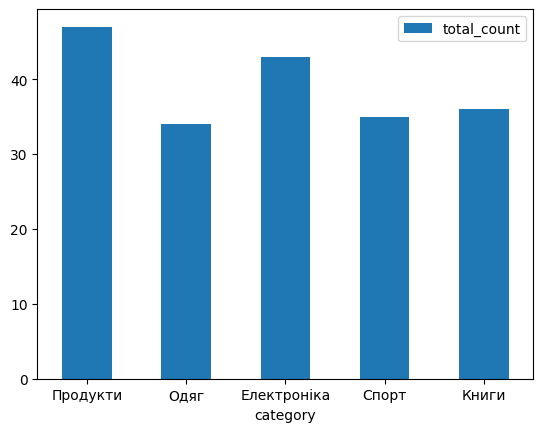

In [10]:
# Ваш код тут
#display(df.groupby('category')['total'].sum())
#display(df.groupby('category')['total'].count())
#display(df.groupby('category')['price'].mean())

display(df.groupby('category').agg(total_sum = ('total', 'sum'),
total_count = ('total', 'count'), price_mean = ('price','mean')).sort_values('total_sum', ascending=False).round(2))
df.groupby('category').agg(total_sum = ('total', 'sum'),
                           total_count = ('total', 'count'),
                           price_mean = ('price','mean')).sort_values('total_sum', ascending=False).plot(kind ='bar', y = 'total_count', rot=0);


**Висновок:** *(Яка категорія приносить найбільший дохід? Чи збігається це з кількістю замовлень?)*
Найбільше грошей приносять продукти, кількість замовлень також в категорії продукти, проте середній прайс більший в катогорії одяг.

---
## Завдання 8 (Середнє). Обробка пропущених значень

1. Заповніть пропущені значення в колонці `price` медіаною цін відповідної категорії (використайте `groupby().transform('median')`).
2. Заповніть пропущені значення в колонці `city` рядком `'Невідомо'`.
3. Пропущені значення в `rating` залиште без змін — поясніть чому у висновку.

Перевірте, що пропусків у `price` та `city` більше немає.

In [11]:
# Ваш код тут
display(df[df['price'].isna()])
median_price = df.groupby('category')['price'].transform('median')
print(median_price)
df['price'] = df['price'].fillna(median_price)
df['total'] = df['total'].fillna(df['price']*df['quantity'])
df['city'] = df['city'].fillna('Невідомо')

print("Пропущених значкнь в City ",df['price'].isna().sum())
print("Пропущених значкнь в Price ", df['city'].isna().sum())


,order_id,date,category,product,city,quantity,price,payment_method,rating,is_returned,total,rank
22,1023,2023-01-23,Продукти,Товар_33,Харків,9,NaN,Картка,5.0,False,NaN,NaN
52,1053,2023-02-22,Продукти,Товар_19,Харків,5,NaN,Онлайн,3.0,False,NaN,NaN
66,1067,2023-03-08,Одяг,Товар_20,Одеса,3,NaN,Готівка,5.0,False,NaN,NaN
72,1073,2023-03-14,Спорт,Товар_29,Харків,2,NaN,Готівка,5.0,False,NaN,NaN
117,1118,2023-04-28,Книги,Товар_49,Львів,7,NaN,Онлайн,5.0,True,NaN,NaN


0      2740.590
1      2448.390
2      2461.385
3      2448.390
4      2448.390
         ...   
195    2461.385
196    2461.385
197    2025.060
198    2448.390
199    2740.590
Name: price, Length: 200, dtype: float64
Пропущених значкнь в City  0
Пропущених значкнь в Price  0


**Висновок:** *(Чому медіана краща за середнє для заповнення цін? Чому пропуски в rating можна залишити?)*

---
## Завдання 9 (Середнє). Додавання обчислюваних колонок

Додайте до датафрейму нові колонки:
1. `month` — місяць замовлення (з колонки `date`).
2. `price_category` — категорія ціни: `'Низька'` (до 500), `'Середня'` (500–2000), `'Висока'` (понад 2000). Використайте `pd.cut()` або `np.select()`.
3. `discount_total` — сума зі знижкою 15%.

In [12]:
# Ваш код тут
import numpy as np
df['month'] = df['date'].dt.month
df['price_category'] = pd.cut(df['price'], bins = [0, 1000, 2000, float('inf')], labels = ['Низька', 'Середня', 'Висока'])
df['price_category2'] = np.select([df['price']<500, (df['price'] >= 500) & (df['price'] <= 2000), df['price']>2000], ['Низька','Середня',  'Висока'], default = '')
df['discount_total'] = (df['total']*0.85).round(2)




**Висновок:** *(Який розподіл цінових категорій? Як метод pd.cut спрощує категоризацію?)*
Розподіл цінових категорій на 3 частини, як Низька, Середня та Висока. Метод cut більш наглядний, займає меньше коду та зрозуміліше.

---
## Завдання 10 (Середнє). Зведена таблиця (pivot table)

Побудуйте зведену таблицю за допомогою `pd.pivot_table()`, де:
- рядки — `city`,
- колонки — `category`,
- значення — сума `total`,
- агрегація — `sum`.

Додайте підсумки по рядках і колонках (`margins=True`).

In [13]:
# Ваш код тут
pd.pivot_table(
  df,
  index = 'city',
  columns = 'category',
  values = 'total',
  aggfunc= 'sum',
  margins = True
)

category,Електроніка,Книги,Одяг,Продукти,Спорт,All
city,,,,,,
Дніпро,65438.16,116118.970,31179.870,147336.56,72244.38,432317.940
Київ,58713.88,87339.030,103754.430,118283.10,113742.95,481833.390
Львів,154285.60,126188.885,74340.690,55768.80,43155.08,453739.055
Невідомо,21012.44,25984.450,46962.310,40508.03,5917.59,140384.820
Одеса,84611.65,26773.570,90218.245,60466.75,65539.34,327609.555
Харків,44068.06,15669.180,135537.230,199766.70,105100.00,500141.170
All,428129.79,398074.085,481992.775,622129.94,405699.34,2336025.930


**Висновок:** *(Яке місто і яка категорія дають найбільший сумарний дохід? Що показують margins?)*
Відповідно до таблиці - продукти дпютьнайбільший дохід, а margings дозволяю виводити підсумок за колонками та рядками. Ав разі необхідності відключати , якщо поставити False.

---
## Завдання 11 (Середнє). Підрахунок унікальних значень і частот

1. Підрахуйте кількість унікальних товарів (`product`) у кожній категорії.
2. Виведіть топ-5 найпопулярніших товарів за кількістю замовлень за допомогою `value_counts()`.
3. Визначте частку кожного способу оплати у відсотках (`normalize=True`).

In [14]:
# Ваш код тут
unik_product = df.groupby('category')['product'].nunique()
print("Unikalni_pridukt ",unik_product)
print("-" * 25)
top_5 = df['product'].value_counts().head(5)
print("Top ", top_5)
print("-" * 25)
print("Частка кожного методу оплати: ",df['payment_method'].value_counts(normalize=True)*100)

Unikalni_pridukt  category
Електроніка    32
Книги          25
Одяг           27
Продукти       30
Спорт          25
Name: product, dtype: int64
-------------------------
Top  product
Товар_33    11
Товар_48     9
Товар_35     9
Товар_22     7
Товар_20     6
Name: count, dtype: int64
-------------------------
Частка кожного методу оплати:  payment_method
Готівка    34.0
Онлайн     33.5
Картка     32.5
Name: proportion, dtype: float64


**Висновок:** *(Який спосіб оплати найпопулярніший? Чи рівномірний розподіл між способами?)*
Готівка за данними має найбільший показник, проте різниця між оплатою "Онлайн" складає всього 0,5%, а різниця з "Картка" - 1,5% Цце динамічний показних, тому найкраща категорія може вже завтра змінитися.

---
## Завдання 12 (Середнє). Аналіз повернень

Розрахуйте рівень повернень (частку повернених замовлень) для кожної категорії та кожного міста. Визначте:
- категорію з найвищим рівнем повернень,
- місто з найнижчим рівнем повернень.

Підказка: використайте `groupby()['is_returned'].mean()`.

In [15]:
# Ваш код тут
Ret_by_city = df.groupby('city').agg(count_id= ('order_id', 'count'), is_ret = ('is_returned', 'sum'))

Ret_by_city['percent'] = (Ret_by_city['is_ret']/Ret_by_city['count_id']*100).round(2)
display(Ret_by_city.sort_values(by='percent'))
print("-" * 25)
Ret_by_category = df.groupby('category').agg(count_id= ('order_id', 'count'), is_ret = ('is_returned', 'sum'))
print(Ret_by_category)
print("-" * 25)
min_ret_by_city = df.groupby('city').agg(count_id= ('order_id', 'count'), is_ret = ('is_returned', 'sum'))
print("-" * 25)

max_category = Ret_by_category['is_ret'].idxmax()
print("Категорія з найвищим рівнем повернень:",max_category)
print("-" * 25)
min_city = Ret_by_city['percent'].idxmin()
print("місто з найнижчим рівнем повернень:",min_city)


,count_id,is_ret,percent
city,,,
Дніпро,38,2,5.26
Харків,39,3,7.69
Невідомо,10,1,10.00
Львів,46,5,10.87
Київ,37,7,18.92
Одеса,30,7,23.33


-------------------------
             count_id  is_ret
category                     
Електроніка        43       7
Книги              37       5
Одяг               35       6
Продукти           49       3
Спорт              36       4
-------------------------
-------------------------
Категорія з найвищим рівнем повернень: Електроніка
-------------------------
місто з найнижчим рівнем повернень: Дніпро


**Висновок:** *(Яка категорія найчастіше повертається? Про що це може свідчити?)*
Категорія Електроніка повертається найбільше, проблема в якості продукції. Клієнти міста Дніпро більш лояльні та/або мають кращу сервісну підтримку.

---
## Завдання 13 (Підвищена складність). Часовий аналіз

1. Встановіть колонку `date` як індекс датафрейму.
2. Розрахуйте щомісячний обсяг продажів (ресемплінг `resample('ME')` або `resample('M')`, sum по `total`).
3. Знайдіть найкращий і найгірший місяці за продажами.
4. Поверніть звичайний числовий індекс (`reset_index()`).

In [27]:
# Ваш код тут




Monthly_sales  date
2023-01-31    351659.990
2023-02-28    354807.150
2023-03-31    305283.785
2023-04-30    322315.225
2023-05-31    335619.620
2023-06-30    386464.610
2023-07-31    279875.550
Freq: ME, Name: total, dtype: float64


/tmp/ipykernel_5523/1194044522.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = df.resample('M')['total'].sum()


**Висновок:** *(Який місяць виявився найуспішнішим? Чи є сезонність у даних?)*

---
## Завдання 14 (Підвищена складність). Накопичувальні показники

1. Відсортуйте датафрейм за датою.
2. Додайте колонку `cumulative_total` — накопичувальний обсяг продажів з початку року (`cumsum()`).
3. Визначте, в який день було досягнуто 50% від загального річного обсягу продажів.

In [49]:
# Ваш код тут
df = df.reset_index()

**Висновок:** *(Коли приблизно була зароблена половина річного доходу? Що це означає для бізнесу?)*

---
## Завдання 15 (Підвищена складність). apply() та lambda

1. Використайте `apply()` з lambda-функцією для створення колонки `total_with_tax`, де ПДВ становить 20%, але лише для замовлень на суму понад 1000 (решта — без змін).
2. Напишіть функцію `classify_rating(r)`, що повертає `'Поганий'` (1–2), `'Нейтральний'` (3), `'Хороший'` (4–5), `'Без оцінки'` (NaN). Застосуйте її до колонки `rating`.

In [50]:
# Ваш код тут
df['total_with_tax'] = df['total'].apply(lambda x: x*1.2 if x>1000 else x)
df['total_with_tax'] = df['total_with_tax'].round(2)
display(df)

import numpy as np

def classify_rating(r):
    if pd.isna(r):
        return 'Без оцінки'
    elif r in [1, 2]:
        return 'Поганий'
    elif r == 3:
        return 'Нейтральний'
    elif r in [4, 5]:
        return 'Хороший'

df['rating_class'] = df['rating'].apply(classify_rating)
display(df)

,date,order_id,category,product,city,quantity,price,payment_method,rating,is_returned,total,rank,month,price_category,price_category2,discount_total,total_with_tax,rating_class
0,2023-01-01,1001,Продукти,Товар_34,Київ,1,963.38,Картка,5.0,False,963.38,188.0,1,Низька,Середня,818.87,963.38,Хороший
1,2023-01-02,1002,Спорт,Товар_6,Львів,6,1086.28,Картка,4.0,False,6517.68,117.0,1,Середня,Середня,5540.03,7821.22,Хороший
2,2023-01-03,1003,Книги,Товар_22,Дніпро,4,1883.84,Готівка,5.0,False,7535.36,109.0,1,Середня,Середня,6405.06,9042.43,Хороший
3,2023-01-04,1004,Спорт,Товар_11,Дніпро,1,2448.39,Картка,5.0,False,2448.39,171.0,1,Висока,Висока,2081.13,2938.07,Хороший
4,2023-01-05,1005,Спорт,Товар_48,Дніпро,7,3110.36,Онлайн,3.0,False,21772.52,28.0,1,Висока,Висока,18506.64,26127.02,Нейтральний
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,2023-07-15,1196,Книги,Товар_42,Львів,4,2618.25,Готівка,4.0,False,10473.00,82.0,7,Висока,Висока,8902.05,12567.60,Хороший
196,2023-07-16,1197,Книги,Товар_6,Львів,1,2976.81,Картка,3.0,False,2976.81,162.0,7,Висока,Висока,2530.29,3572.17,Нейтральний
197,2023-07-17,1198,Електроніка,Товар_15,Львів,8,2025.06,Онлайн,5.0,False,16200.48,55.0,7,Висока,Висока,13770.41,19440.58,Хороший
198,2023-07-18,1199,Спорт,Товар_43,Одеса,1,321.07,Картка,5.0,False,321.07,194.0,7,Низька,Низька,272.91,321.07,Хороший


,date,order_id,category,product,city,quantity,price,payment_method,rating,is_returned,total,rank,month,price_category,price_category2,discount_total,total_with_tax,rating_class
0,2023-01-01,1001,Продукти,Товар_34,Київ,1,963.38,Картка,5.0,False,963.38,188.0,1,Низька,Середня,818.87,963.38,Хороший
1,2023-01-02,1002,Спорт,Товар_6,Львів,6,1086.28,Картка,4.0,False,6517.68,117.0,1,Середня,Середня,5540.03,7821.22,Хороший
2,2023-01-03,1003,Книги,Товар_22,Дніпро,4,1883.84,Готівка,5.0,False,7535.36,109.0,1,Середня,Середня,6405.06,9042.43,Хороший
3,2023-01-04,1004,Спорт,Товар_11,Дніпро,1,2448.39,Картка,5.0,False,2448.39,171.0,1,Висока,Висока,2081.13,2938.07,Хороший
4,2023-01-05,1005,Спорт,Товар_48,Дніпро,7,3110.36,Онлайн,3.0,False,21772.52,28.0,1,Висока,Висока,18506.64,26127.02,Нейтральний
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,2023-07-15,1196,Книги,Товар_42,Львів,4,2618.25,Готівка,4.0,False,10473.00,82.0,7,Висока,Висока,8902.05,12567.60,Хороший
196,2023-07-16,1197,Книги,Товар_6,Львів,1,2976.81,Картка,3.0,False,2976.81,162.0,7,Висока,Висока,2530.29,3572.17,Нейтральний
197,2023-07-17,1198,Електроніка,Товар_15,Львів,8,2025.06,Онлайн,5.0,False,16200.48,55.0,7,Висока,Висока,13770.41,19440.58,Хороший
198,2023-07-18,1199,Спорт,Товар_43,Одеса,1,321.07,Картка,5.0,False,321.07,194.0,7,Низька,Низька,272.91,321.07,Хороший


**Висновок:** *(Яка частка замовлень має хороший рейтинг? Коли apply кращий за vectorized-операції?)*

---
## Завдання 16 (Підвищена складність). Злиття датафреймів (merge)

Створіть додатковий датафрейм `df_discounts` з колонками `category` та `discount_pct` (різні знижки для кожної категорії). Об'єднайте його з основним датафреймом за допомогою `pd.merge()` та розрахуйте `final_total` — суму після застосування відповідної знижки.

```python
df_discounts = pd.DataFrame({
    'category':     ['Електроніка', 'Одяг', 'Книги', 'Продукти', 'Спорт'],
    'discount_pct': [0.10, 0.20, 0.05, 0.00, 0.15]
})
```

In [19]:
df_discounts = pd.DataFrame({
    'category':     ['Електроніка', 'Одяг', 'Книги', 'Продукти', 'Спорт'],
    'discount_pct': [0.10, 0.20, 0.05, 0.00, 0.15]
})

# Ваш код тут


**Висновок:** *(Яка категорія отримала найбільшу сумарну знижку? Коли варто використовувати merge замість map?)*

---
## Завдання 17 (Підвищена складність). Групові трансформації

1. Додайте колонку `city_avg_total` — середня сума замовлення по місту (для кожного рядка підставте середнє по його місту), використайте `groupby().transform('mean')`.
2. Додайте колонку `above_city_avg` — булева колонка, що показує, чи перевищує замовлення середнє по місту.
3. Підрахуйте частку таких замовлень для кожного міста.

In [20]:
# Ваш код тут


**Висновок:** *(Чим transform відрізняється від звичайного groupby? У якому місті найбільша частка великих замовлень?)*

---
## Завдання 18 (Складне). Ковзне середнє та аномалії

1. Згрупуйте дані за місяцем та розрахуйте щоденну виручку.
2. Розрахуйте 7-денне ковзне середнє виручки (`rolling(7).mean()`).
3. Визначте дні-аномалії: дні, коли виручка відхилилася від ковзного середнього більш ніж на 2 стандартних відхилення.

In [21]:
# Ваш код тут


**Висновок:** *(Скільки аномальних днів виявлено? Що може бути причиною різких відхилень виручки?)*

---
## Завдання 19 (Складне). Когортний аналіз

Виконайте спрощений когортний аналіз за місяцем першого замовлення:
1. Для кожного товару (`product`) знайдіть місяць першого продажу — це його «когорта».
2. Об'єднайте цю інформацію з основним датафреймом.
3. Побудуйте зведену таблицю: когорта (місяць першого продажу) проти місяця замовлення, значення — кількість замовлень.

Підказка: використайте `groupby('product')['date'].transform('min')` та `dt.to_period('M')`.

In [22]:
# Ваш код тут


**Висновок:** *(Що показує когортна таблиця? Чи продовжують товари з першої когорти продаватися в наступних місяцях?)*

---
## Завдання 20 (Складне). Підсумковий звіт

Сформуйте підсумковий звіт у вигляді одного датафрейму `summary_report`, що містить для кожної категорії:
- загальний дохід (`total_revenue`),
- кількість замовлень (`order_count`),
- середній чек (`avg_order_value`),
- частку доходу від загального (`revenue_share_pct`),
- рівень повернень у відсотках (`return_rate_pct`),
- середній рейтинг без NaN (`avg_rating`).

Відсортуйте за `total_revenue` спадно. Збережіть результат у файл `summary_report.csv`.

In [23]:
# Ваш код тут


**Висновок:** *(Яка категорія є лідером за доходом? Чи є зв'язок між рейтингом та рівнем повернень? Які рекомендації можна дати бізнесу на основі цього звіту?)*

---
## Загальні підсумки

Після виконання всіх завдань дайте відповідь на такі питання:

1. Які методи pandas виявилися для вас найбільш корисними?
2. Які труднощі виникли під час роботи з пропущеними значеннями?
3. Що можна додати до аналізу, щоб зробити його більш повним?

*(Ваші відповіді тут)*